In [2]:
# All required libraries: 

import pandas as pd
import xlrd
import openpyxl

import matplotlib.dates as mdates
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# Data 

1. Brent Crude Oil 

    reference   : https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=PET&s=RBRTE&f=
    Frequency   : Monthly
    Range       : May-1987 to Feb-2026  
    UoM         : European Brent Spot Price FOB ( Dollars / Barrel)


2. Real Food Price Indices 

    reference: https://www.fao.org/worldfoodsituation/foodpricesindex/en/
    Frequency   : Monthly
    Range       : Jan-1990 to Feb-2026  
    UoM         : an Index

    More Information:   FAO Food Price Index (FFPI) is a measure of the monthly change in       
                        international prices of a basket of food commodities...

                        Only Food Price Index is considered

3. Global Price of Natural Gas 

    reference: https://fred.stlouisfed.org/series/PNGASEUUSDM
    Frequency   : Monthly
    Range       : Jan-1992 to Feb-2026  
    UoM         : U.S. Dollars per Million Metric British Thermal Unit

4. Fertilizer Cost 
    reference: https://fred.stlouisfed.org/series/PCU325311325311
    Frequency   : Monthly
    Range       : Jan-1975 to Feb-2026  
    UoM         : An index (considering Index =100 (for year Dec 1979) )




1. Oil Prize

In [3]:
brent = pd.read_excel('data/RBRTEm.xls',sheet_name='Data 1')

brent.drop(brent.index[:2],inplace=True) # removed unnecessary rows on the top

brent.rename(columns={"Back to Contents":"Date", "Data 1: Europe Brent Spot Price FOB (Dollars per Barrel)":"Oil Prize" },inplace=True)

brent['Date'] = pd.to_datetime(brent['Date']).dt.strftime('%m-%Y')

brent = brent.set_index('Date')

In [4]:
brent.head()

,Oil Prize
Date,
05-1987,18.58
06-1987,18.86
07-1987,19.86
08-1987,18.98
09-1987,18.31


2. Food Prizes

In [5]:
food = pd.read_excel('data/ffpi-data-2026-03.xlsx',sheet_name='Indices_Monthly_Real')
food.drop(food.index[:2],inplace=True)

# Renaming names of columns (only Food Index is assumed)
food.rename(columns={"Unnamed: 0":"Date"},inplace=True)
food.rename(columns={"FAO Monthly Real Food Price Indices":"Food_indice"},inplace=True)
food.rename(columns={"Unnamed: 2":"MeatPrice_indice"},inplace=True)
food.rename(columns={"Unnamed: 3":"DairyPrice_indice"},inplace=True)
food.rename(columns={"Unnamed: 4":"CerealsPrice_indice"},inplace=True)
food.rename(columns={"Unnamed: 5":"OilsPrice_indice"},inplace=True)
food.rename(columns={"Unnamed: 6":"SugarPrice_indice"},inplace=True)

food['Date'] = pd.to_datetime(food['Date']).dt.strftime('%m-%Y')
food = food.set_index('Date')

food = food.drop(['MeatPrice_indice','DairyPrice_indice','CerealsPrice_indice','OilsPrice_indice','SugarPrice_indice'],axis = 1)

In [6]:
food.head()

,Food_indice
Date,
01-1990,77.989622
02-1990,78.333434
03-1990,77.492017
04-1990,79.891791
05-1990,78.217916


3. Natural Gas Prize

In [7]:
globalNaturalGas = pd.read_csv('data/global_prize_natural_gas.csv')

globalNaturalGas.rename(columns={"observation_date":"Date"},inplace=True)
globalNaturalGas.rename(columns={"PNGASEUUSDM":"GlobalNaturalGasSpotPrice"},inplace=True)

globalNaturalGas['Date'] = pd.to_datetime(globalNaturalGas['Date']).dt.strftime('%m-%Y')
globalNaturalGas = globalNaturalGas.set_index('Date')

In [8]:
globalNaturalGas.head()

,GlobalNaturalGasSpotPrice
Date,
01-1992,2.38
02-1992,2.38
03-1992,2.38
04-1992,2.34
05-1992,2.34


4. Fertilizer Cost

In [10]:
fertilizer = pd.read_csv('data/PCU325311325311.csv')

fertilizer.rename(columns={"observation_date":"Date"},inplace=True)
fertilizer.rename(columns={"PCU325311325311":"FertilizerCost"},inplace=True)

fertilizer['Date'] = pd.to_datetime(fertilizer['Date']).dt.strftime('%m-%Y')
fertilizer = fertilizer.set_index('Date')


In [11]:
fertilizer.head()

,FertilizerCost
Date,
12-1975,88.1
01-1976,87.6
02-1976,85.0
03-1976,84.8
04-1976,84.7


Combining the data

In [13]:

combineddf = pd.concat([fertilizer,brent, food, globalNaturalGas], axis=1, join = 'outer')

combineddf.dropna(inplace=True)

Data Visualization

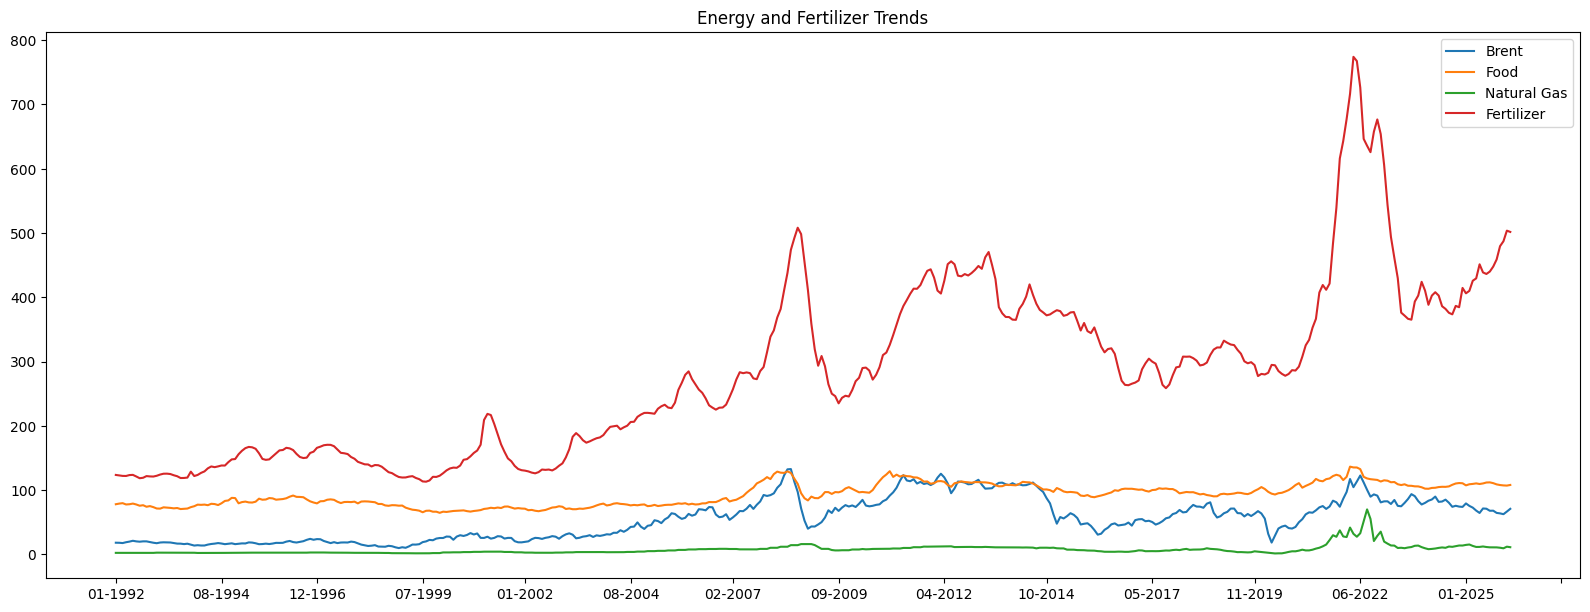

In [18]:
plt.figure(figsize=(16,6))
plt.plot(combineddf.index,combineddf['Oil Prize'], label='Brent')
plt.plot(combineddf.index,combineddf['Food_indice'], label='Food')
plt.plot(combineddf.index,combineddf['GlobalNaturalGasSpotPrice'], label='Natural Gas')
plt.plot(combineddf.index,combineddf['FertilizerCost'], label='Fertilizer')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()


plt.legend()
plt.title("Energy and Fertilizer Trends")
plt.show()

Scaled Data

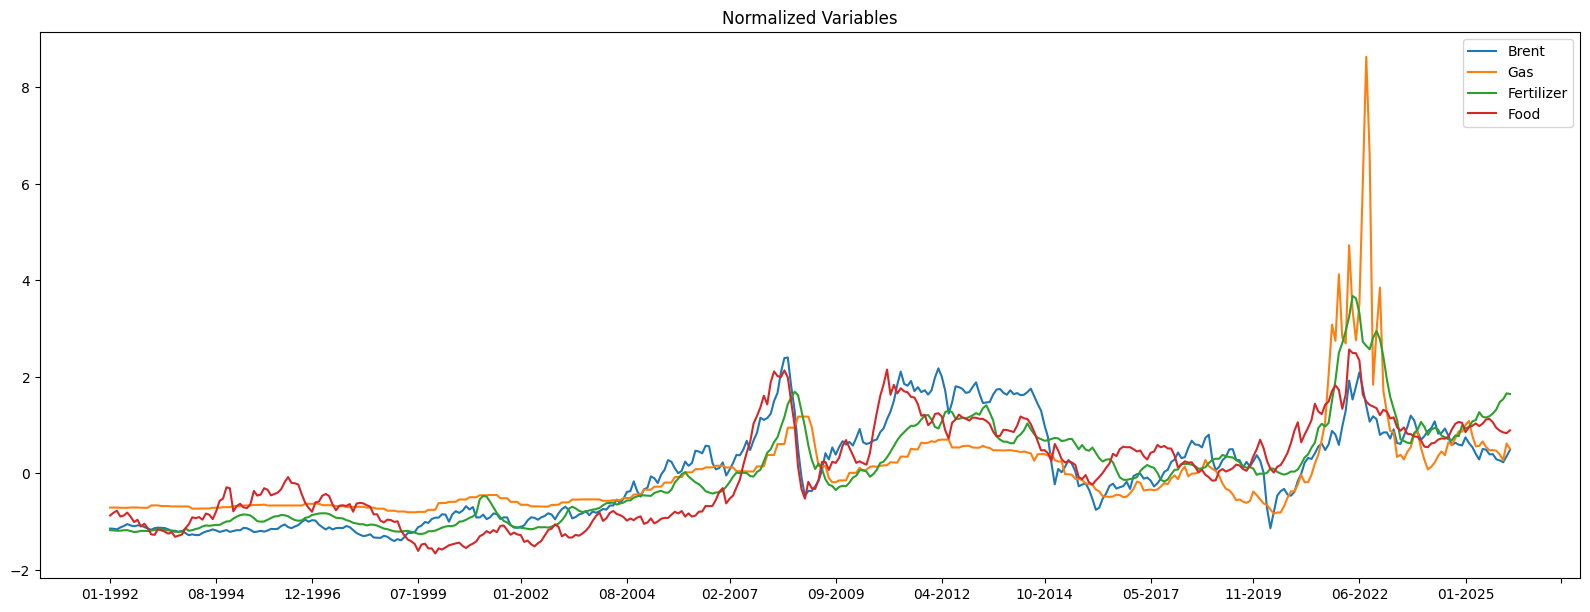

In [ ]:
scaler = StandardScaler()

scaled_array = scaler.fit_transform(combineddf)

scaled_df = pd.DataFrame(scaled_array, columns=combineddf.columns, index=combineddf.index)

plt.figure(figsize=(16,6))

plt.plot(scaled_df['Oil Prize'], label='Brent')
plt.plot(scaled_df['GlobalNaturalGasSpotPrice'], label='Gas')
plt.plot(scaled_df['FertilizerCost'], label='Fertilizer')
plt.plot(scaled_df['Food_indice'], label='Food')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))


plt.tight_layout()

plt.legend()
plt.title("Normalized Variables")

plt.show()

Correlation between variables

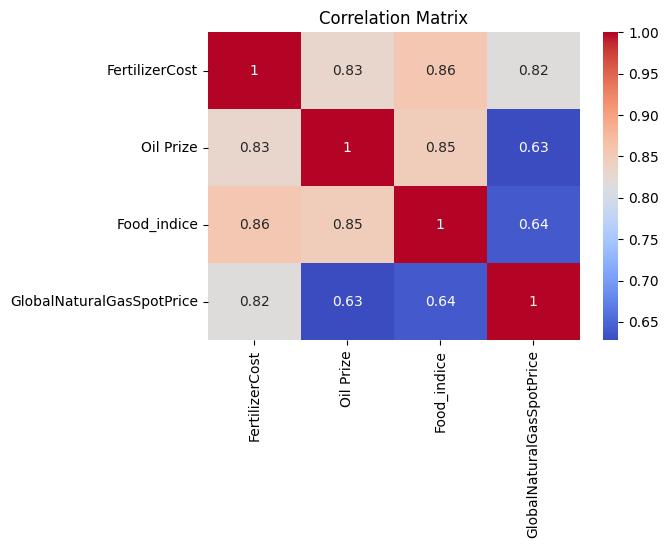

In [24]:
corr = scaled_df.corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Applying Static PCA

In [25]:
pca = PCA()
principleComponents = pca.fit_transform(scaled_df)

pc = pd.DataFrame(
    principleComponents,
    columns=['PC1','PC2','PC3','PC4']
)

pca.explained_variance_ratio_

clean_data = combineddf.reset_index()

pc['Date'] = clean_data['Date']

In [27]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1','PC2','PC3','PC4'],
    index=scaled_df.columns
)
print(loadings)

                                PC1       PC2       PC3       PC4
FertilizerCost             0.529370  0.103327 -0.159314  0.826867
Oil Prize                  0.499949 -0.442885  0.733959 -0.123316
Food_indice                0.506260 -0.397916 -0.652172 -0.400045
GlobalNaturalGasSpotPrice  0.462081  0.796768  0.102930 -0.375564


Plot of PCs

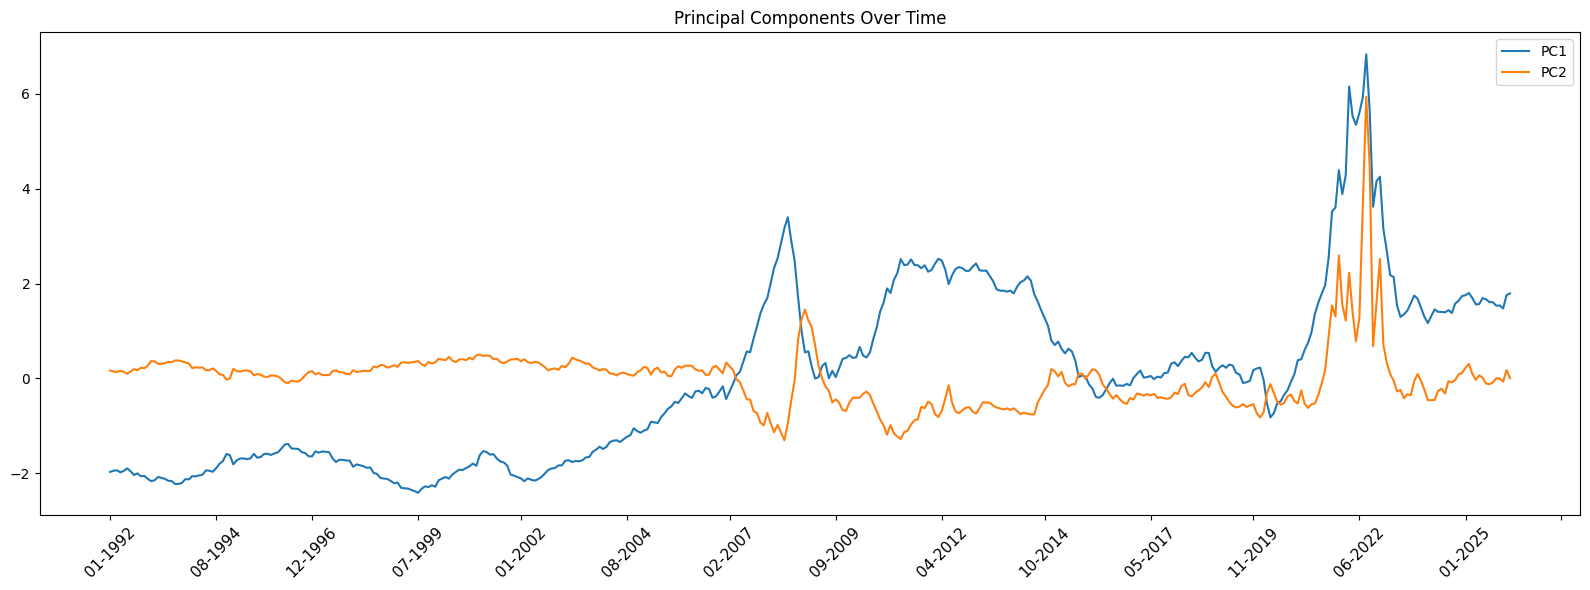

In [28]:

plt.figure(figsize=(16,6))

plt.plot(pc['Date'], pc['PC1'], label='PC1')
plt.plot(pc['Date'], pc['PC2'], label='PC2')
# plt.plot(pc['Date'], pc['PC3'], label='PC3')
# plt.plot(pc['Date'], pc['PC4'], label='PC4')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))

plt.xticks(rotation=45, fontsize=11)

plt.legend()
plt.title("Principal Components Over Time")

plt.tight_layout()
plt.show()

Lag to know the cause & effect 

1 0.839359674846148
2 0.8460822332861543
3 0.8485524903708911
4 0.846196710211018
5 0.8412167364059353
6 0.8335006209148175
7 0.8234914986144224
8 0.810498894042831
9 0.7953020871026346
10 0.7788975972675147
11 0.7609295466210652
12 0.7428881934327524


Text(0, 0.5, 'Correlation')

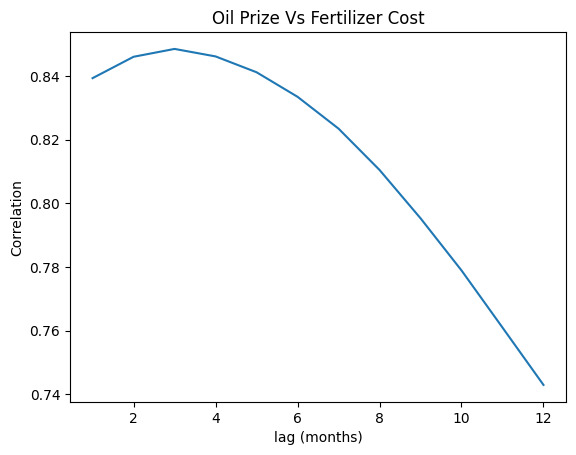

In [41]:
lag_list    = []
corr_list   = []

for lag in range(1,13):
    corr = scaled_df['Oil Prize'].shift(lag).corr(scaled_df['FertilizerCost'])
    print(lag, corr)
    lag_list.append(lag)
    corr_list.append(corr)
    
plt.plot(lag_list,corr_list)

plt.title('Oil Prize Vs Fertilizer Cost')
plt.xlabel('lag (months)')
plt.ylabel('Correlation')


Text(0, 0.5, 'Correlation')

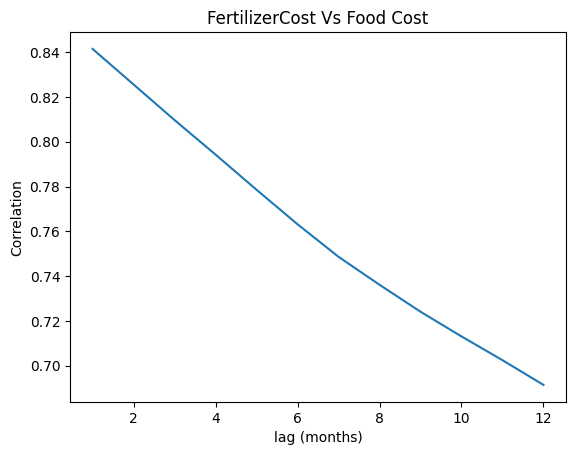

In [42]:
lag_list    = []
corr_list   = []

for lag in range(1,13):
    corr = scaled_df['FertilizerCost'].shift(lag).corr(scaled_df['Food_indice'])
    
    lag_list.append(lag)
    corr_list.append(corr)
    
plt.plot(lag_list,corr_list)

plt.title('FertilizerCost Vs Food Cost')
plt.xlabel('lag (months)')
plt.ylabel('Correlation')

Text(0, 0.5, 'Correlation')

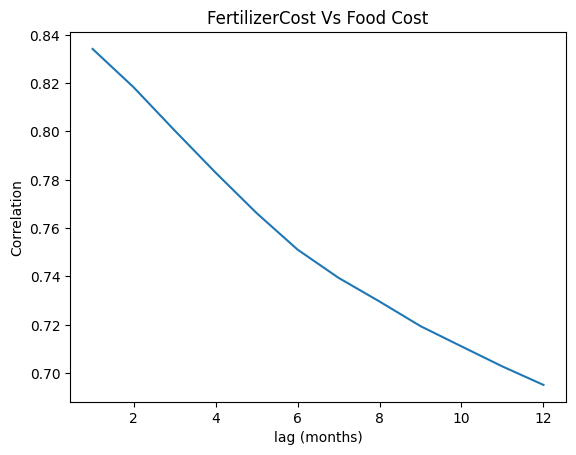

In [45]:
lag_list    = []
corr_list   = []

for lag in range(1,13):
    corr = scaled_df['Oil Prize'].shift(lag).corr(scaled_df['Food_indice'])
    
    lag_list.append(lag)
    corr_list.append(corr)

plt.plot(lag_list,corr_list)

plt.title('FertilizerCost Vs Food Cost')
plt.xlabel('lag (months)')
plt.ylabel('Correlation')

From above plots it is clear that Oil-Prize variation is the cause for the variation in all of the rest variables 

# Rolling PCA

Instead of doing rolling PC on the variables, it is done on their time-differences

Further, windows of different sizes ( in months) are used to check the robustness

In [48]:
time_diff = scaled_df.diff().dropna()

Window = 60

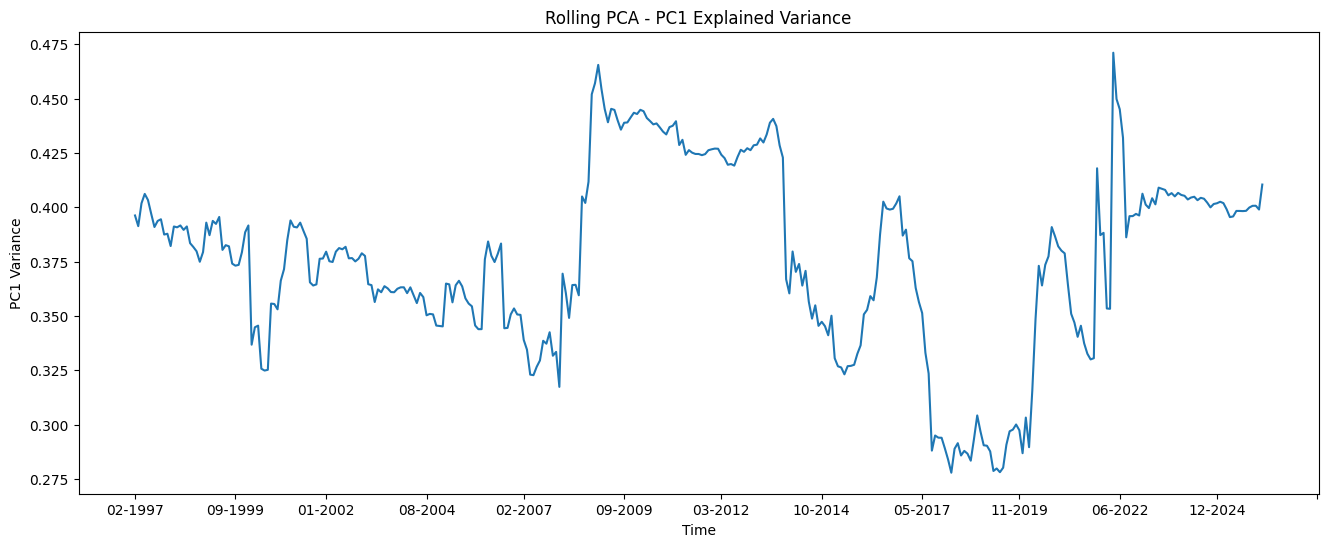

In [50]:
window = 60

rolling_pc1_60 = []
dates = []

for i in range(window, len(time_diff)):
    
    subset = time_diff.iloc[i-window:i]
    
    scaler = StandardScaler()
    X_scaled1 = scaler.fit_transform(subset)
    
    pca = PCA()
    pca.fit(X_scaled1)
    
    rolling_pc1_60.append(pca.explained_variance_ratio_[0])
    dates.append(time_diff.index[i])



rolling_df_60 = pd.DataFrame({
    'Date': dates,
    'PC1': rolling_pc1_60
})

rolling_df_60.set_index('Date', inplace=True)


plt.figure(figsize=(16,6))

plt.plot(rolling_df_60.index, rolling_df_60['PC1'])

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))

plt.title("Rolling PCA - PC1 Explained Variance")
plt.ylabel("PC1 Variance")
plt.xlabel("Time")

plt.show()

Window = 30 

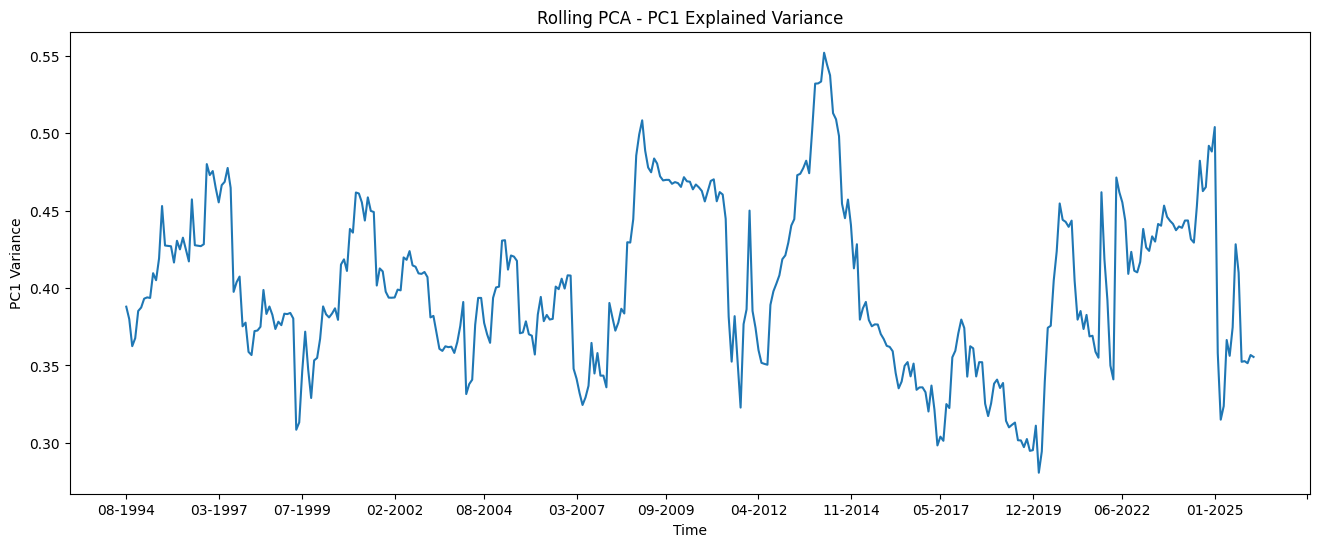

In [51]:
window = 30

rolling_pc1_30 = []
dates = []

for i in range(window, len(time_diff)):
    
    subset = time_diff.iloc[i-window:i]
    
    scaler = StandardScaler()
    X_scaled1 = scaler.fit_transform(subset)
    
    pca = PCA()
    pca.fit(X_scaled1)
    
    rolling_pc1_30.append(pca.explained_variance_ratio_[0])
    dates.append(time_diff.index[i])



rolling_df_30 = pd.DataFrame({
    'Date': dates,
    'PC1': rolling_pc1_30
})

rolling_df_30.set_index('Date', inplace=True)


plt.figure(figsize=(16,6))

plt.plot(rolling_df_30.index, rolling_df_30['PC1'])

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))

plt.title("Rolling PCA - PC1 Explained Variance")
plt.ylabel("PC1 Variance")
plt.xlabel("Time")

plt.show()

window = 84

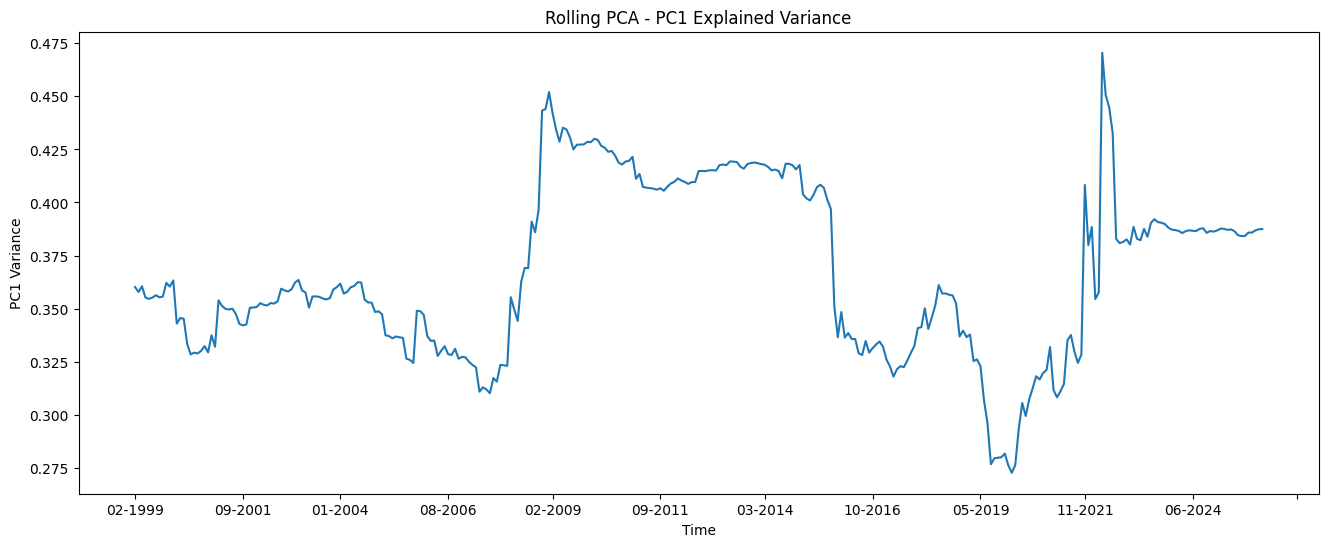

In [52]:
window = 84

rolling_pc1_84 = []
dates = []

for i in range(window, len(time_diff)):
    
    subset = time_diff.iloc[i-window:i]
    
    scaler = StandardScaler()
    X_scaled1 = scaler.fit_transform(subset)
    
    pca = PCA()
    pca.fit(X_scaled1)
    
    rolling_pc1_84.append(pca.explained_variance_ratio_[0])
    dates.append(time_diff.index[i])



rolling_df_84 = pd.DataFrame({
    'Date': dates,
    'PC1': rolling_pc1_84
})

rolling_df_84.set_index('Date', inplace=True)


plt.figure(figsize=(16,6))

plt.plot(rolling_df_84.index, rolling_df_84['PC1'])

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))

plt.title("Rolling PCA - PC1 Explained Variance")
plt.ylabel("PC1 Variance")
plt.xlabel("Time")

plt.show()

Plots of all dynamic PCs together to check if they vary similarly:

In [68]:

def rolling_pca(data, window):

    dates =     []
    pc1_var =   []
    pc2_var =   []
    loadings =  []

    for i in range(window, len(data)):
        
        subset = data.iloc[i-window:i]

        scaler = StandardScaler()

        X_scaled = scaler.fit_transform(subset)

        pca = PCA()

        pca.fit(X_scaled)

        pc1_var.append(pca.explained_variance_ratio_[0])
        
        pc2_var.append(pca.explained_variance_ratio_[1])

        loadings.append(pca.components_[0])

        dates.append(data.index[i])

    var_df = pd.DataFrame({
        'PC1': pc1_var,
        'PC2': pc2_var
    }, index=dates)

    load_df = pd.DataFrame(
        loadings,
        columns=data.columns,
        index=dates
    )

    return var_df, load_df

loading (corresponding to PC1) and variances for PCs in each window

In [70]:
var30, load30 = rolling_pca(time_diff, 30)
var60, load60 = rolling_pca(time_diff, 60)
var84, load84 = rolling_pca(time_diff, 84)

load30_abs = load30.abs()
load60_abs = load60.abs()
load84_abs = load84.abs()

load30_s = load30_abs.rolling(12).mean()
load60_s = load60_abs.rolling(12).mean()
load84_s = load84_abs.rolling(12).mean()

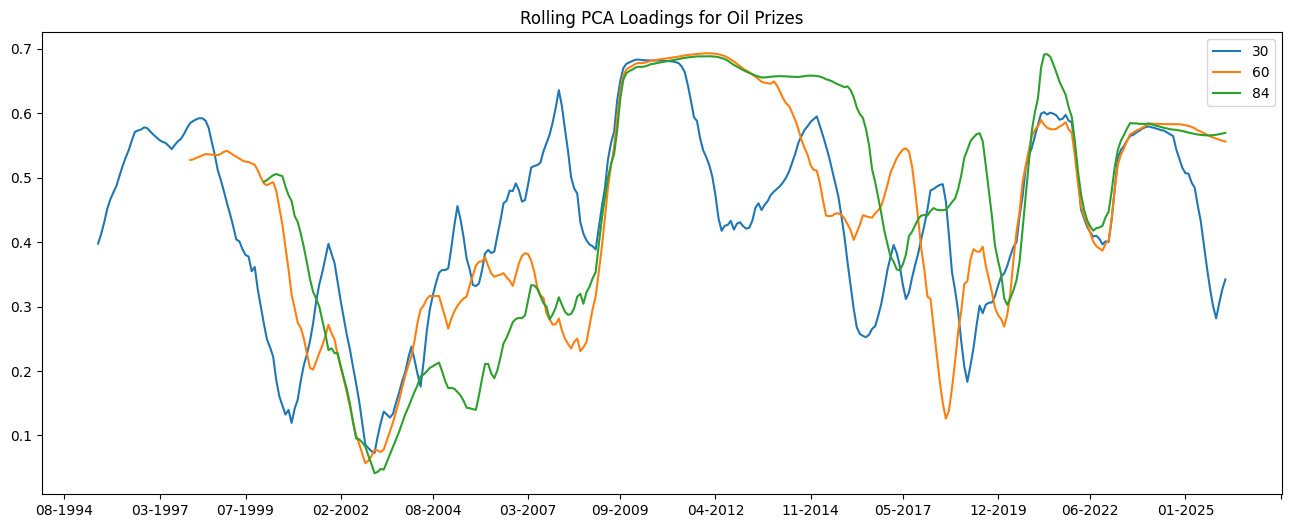

In [57]:
plt.figure(figsize=(16,6))
plt.plot(load30_s['Oil Prize'],label='30')
plt.plot(load60_s['Oil Prize'],label='60')
plt.plot(load84_s['Oil Prize'],label='84')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))

plt.legend()
plt.title("Rolling PCA Loadings for Oil Prizes")

plt.show()

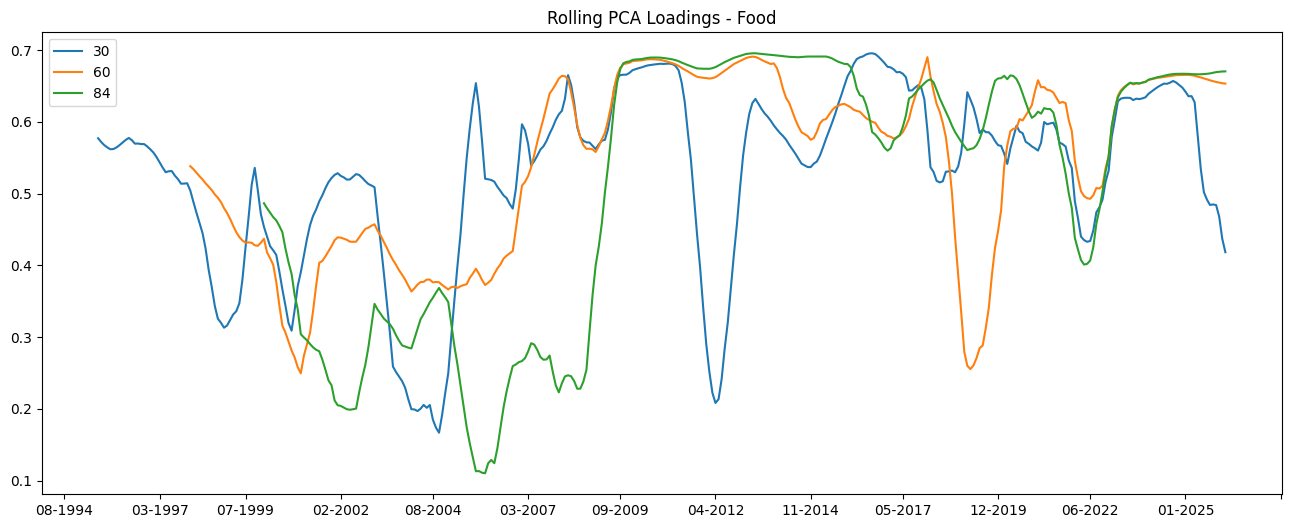

In [58]:
plt.figure(figsize=(16,6))
plt.plot(load30_s['Food_indice'],label='30')
plt.plot(load60_s['Food_indice'],label='60')
plt.plot(load84_s['Food_indice'],label='84')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))

plt.legend()
plt.title("Rolling PCA Loadings - Food")

plt.show()

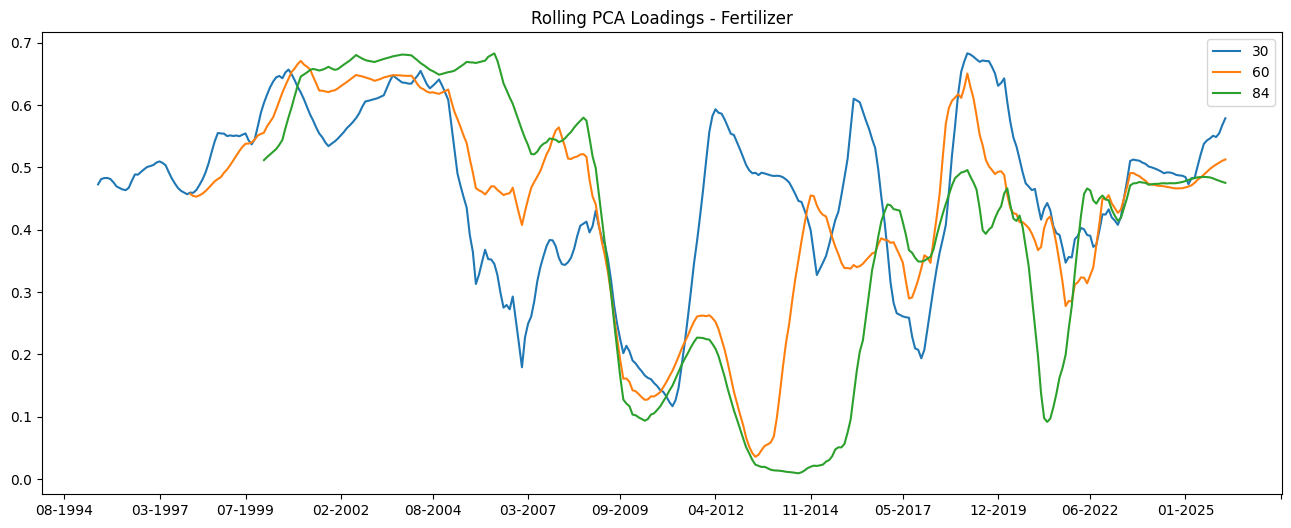

In [59]:
plt.figure(figsize=(16,6))
plt.plot(load30_s['FertilizerCost'],label='30')
plt.plot(load60_s['FertilizerCost'],label='60')
plt.plot(load84_s['FertilizerCost'],label='84')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))

plt.legend()
plt.title("Rolling PCA Loadings - Fertilizer")

plt.show()

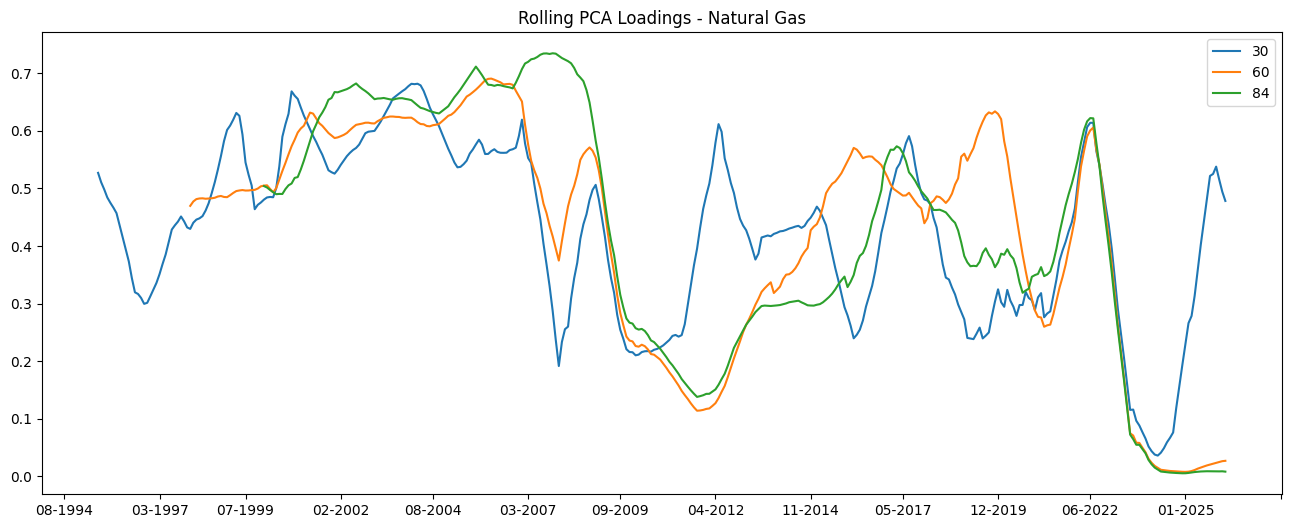

In [60]:
plt.figure(figsize=(16,6))
plt.plot(load30_s['GlobalNaturalGasSpotPrice'],label='30')
plt.plot(load60_s['GlobalNaturalGasSpotPrice'],label='60')
plt.plot(load84_s['GlobalNaturalGasSpotPrice'],label='84')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))

plt.legend()
plt.title("Rolling PCA Loadings - Natural Gas")

plt.show()

Above plots show that the loadings are almost similar for all the variables in PC1 (which is mostly dominating)

Rolling Correlations : Oil Vs Food 

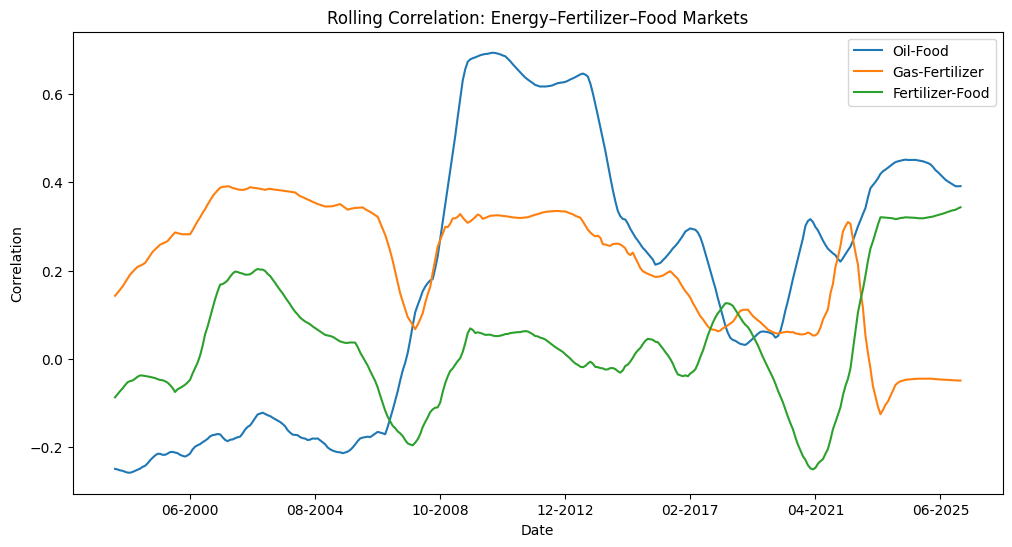

Oil-Food           0.174994
Gas-Fertilizer     0.212109
Fertilizer-Food    0.038547
dtype: float64

In [63]:
window = 60  # same as rolling PCA

rolling_corr = pd.DataFrame({
    'Oil-Food':time_diff['Oil Prize'].rolling(window).corr(time_diff['Food_indice']),
    'Gas-Fertilizer': time_diff['GlobalNaturalGasSpotPrice'].rolling(window).corr(time_diff['FertilizerCost']),
    'Fertilizer-Food': time_diff['FertilizerCost'].rolling(window).corr(time_diff['Food_indice'])
})

rolling_corr_smooth = rolling_corr.rolling(12).mean()

rolling_corr_smooth.plot(figsize=(12,6))
plt.title('Rolling Correlation: Energy–Fertilizer–Food Markets')
plt.ylabel('Correlation')
plt.show()

rolling_corr_smooth.mean()

1. Pre-2008: Weak Coupling 

Oil–Food: Negative 
Gas–Fertilizer: Positive 
Fertilizer–Food: Weak

Interpretation:

Energy (Oil) and food markets were loosely connected

Fertilizer market partially linked to gas

This suggests:

Before 2008, energy, fertilizer, and food markets operated largely independently.


2. 2008–2013: Strong System Coupling (Peiod : Crisis)

Oil–Food: Very strong
Gas–Fertilizer: 0.3
Fertilizer–Food: mildly positive

This aligns with:

2008 Financial Crisis

2008 crisis triggered strong synchronization across energy and food markets.

3. 2014–2019: Decoupling Phase

Oil–Food: Declines
Gas–Fertilizer: Decreases
Fertilizer–Food: Fluctuates

This corresponds to:

2014 Oil price crash

Interpretation:

Markets partially decoupled following oil price collapse.

4. 2020–2022: Structural Shock (COVID + Ukraine War)

Fertilizer–Food: drops ~ −0.25
Oil–Food: Fluctuates
Gas–Fertilizer: Volatile


5. Post-2022

Fertilizer–Food: spikes strong (~0.35)
Oil–Food: Rise again (~0.45)

This suggests:

The 2022 energy crisis resulted in strong coupling.


Three regimes:

Pre-2008 → Weak coupling
2008–2013 → Strong coupling
Post-2022 → Re-coupling

# High vs Low Coupling Periods: 

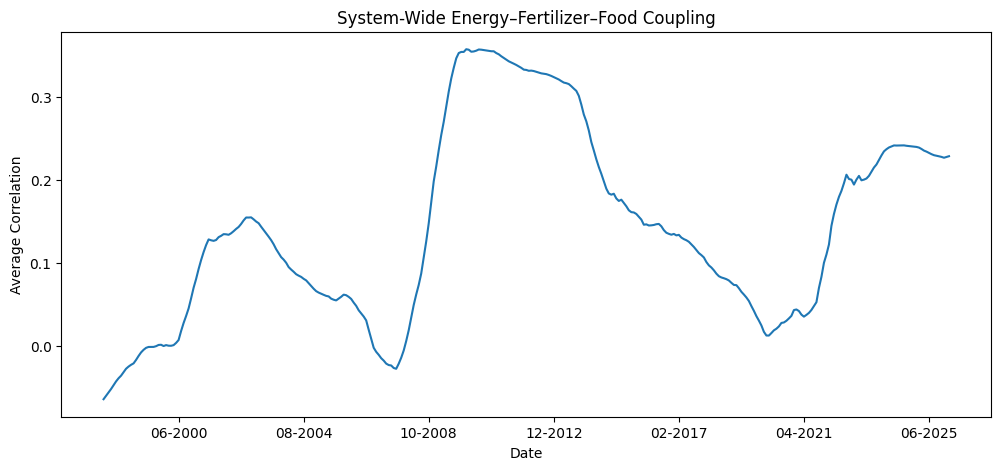

In [72]:
avg_corr = rolling_corr_smooth.mean(axis=1)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
avg_corr.plot()
plt.title('System-Wide Energy–Fertilizer–Food Coupling')
plt.ylabel('Average Correlation')
plt.show()  

In [74]:
#Assume: 
high_threshold = avg_corr.quantile(0.75)
low_threshold = avg_corr.quantile(0.25)

regime = pd.Series(index=avg_corr.index, dtype="object")

regime[avg_corr >= high_threshold] = "High Coupling"
regime[avg_corr <= low_threshold] = "Low Coupling"
regime[(avg_corr > low_threshold) & (avg_corr < high_threshold)] = "Medium Coupling"

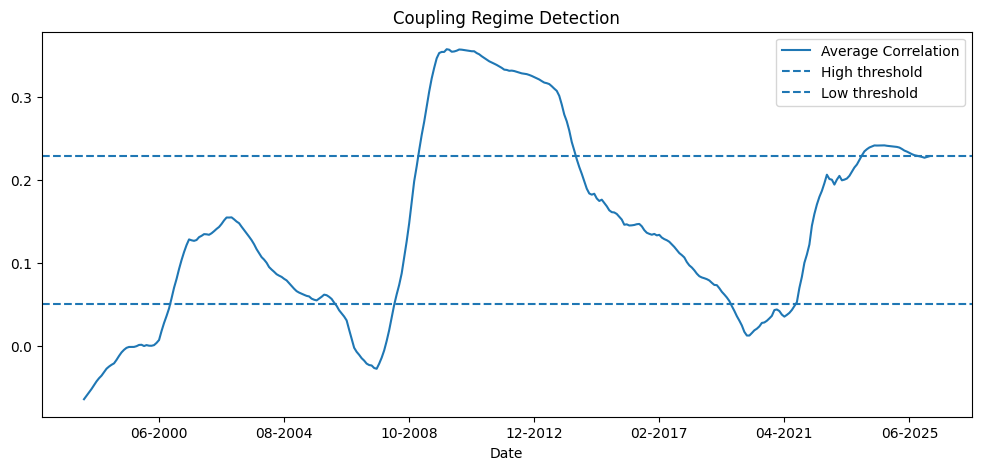

In [75]:
plt.figure(figsize=(12,5))
avg_corr.plot(label='Average Correlation')

plt.axhline(high_threshold, linestyle='--', label='High threshold')
plt.axhline(low_threshold, linestyle='--', label='Low threshold')

plt.title('Coupling Regime Detection')
plt.legend()
plt.show()

In [77]:
#Period with high Correlation:

high_periods = avg_corr[avg_corr >= high_threshold]
print(high_periods.head())

Date
02-2009    0.235647
03-2009    0.253860
04-2009    0.269832
05-2009    0.288195
06-2009    0.306156
dtype: float64


In [168]:
print("High coupling average:", avg_corr[avg_corr >= high_threshold].mean())
print("Low coupling average:", avg_corr[avg_corr <= low_threshold].mean())

High coupling average: 0.3021743083113186
Low coupling average: 0.006011529612703457


# Variance explained by PC1 ( we assume fixed window of 60 months)

In [78]:
from sklearn.decomposition import PCA
import pandas as pd

window = 60

pc1_var = []

for i in range(window, len(scaled_df)):
    subset = scaled_df.iloc[i-window:i]
    
    pca = PCA()
    pca.fit(subset)
    
    pc1_var.append(pca.explained_variance_ratio_[0])

pc1_var = pd.Series(pc1_var, index=scaled_df.index[window:])

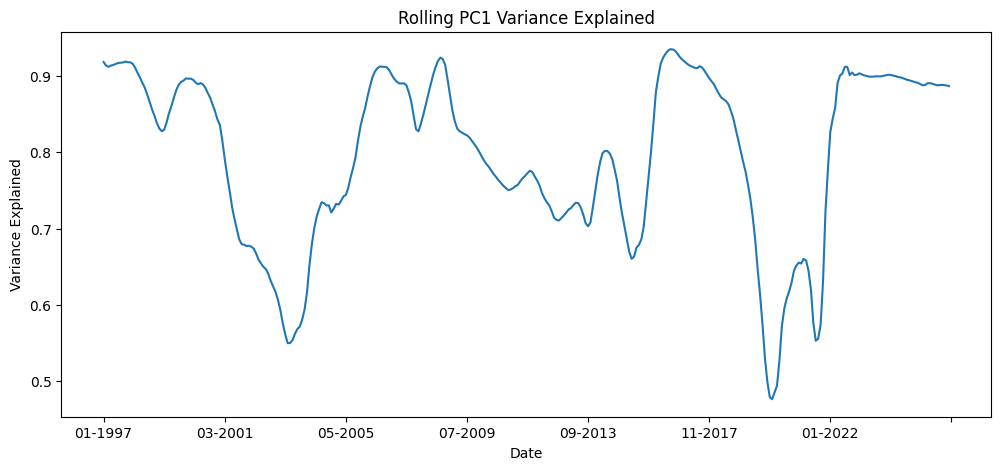

In [80]:

plt.figure(figsize=(12,5))
pc1_var.plot()

plt.title("Rolling PC1 Variance Explained")
plt.ylabel("Variance Explained")
plt.xlabel("Date")

plt.show()

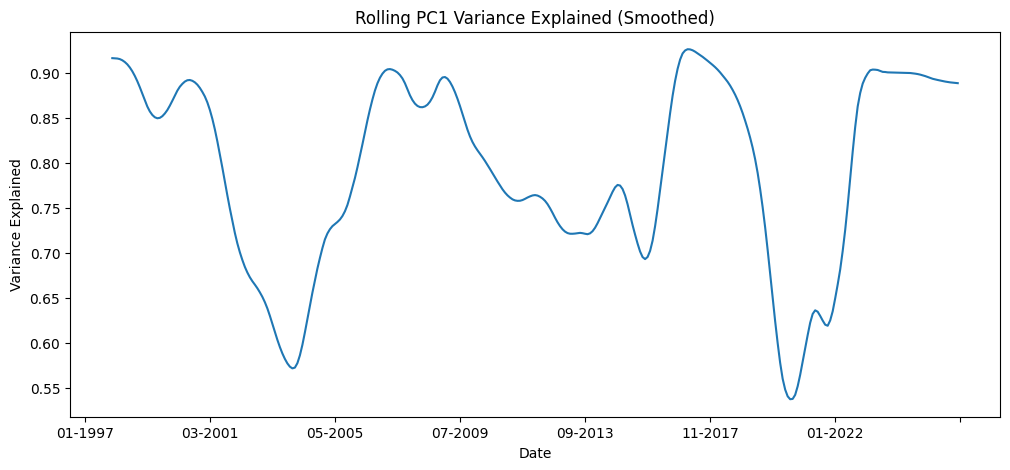

In [81]:
pc1_var_smooth = pc1_var.rolling(12).mean()

plt.figure(figsize=(12,5))
pc1_var_smooth.plot()

plt.title("Rolling PC1 Variance Explained (Smoothed)")
plt.ylabel("Variance Explained")

plt.show()